# Neural style transfer

This notebook follows the official PyTorch Neural Transfer tutorial: https://docs.pytorch.org/tutorials/advanced/neural_style_tutorial.html

The goal is to generate a new image that keeps the content structure of `dancing.jpg` while borrowing the artistic style of `picasso.jpg`.


## 1. Select the PyTorch device

A device is where PyTorch runs tensor math. We use CUDA when it is available because style transfer repeatedly updates image pixels and runs faster on the GPU.


In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 2. Load the content and style images

The image loader opens each `.jpg`, resizes it, converts it into a PyTorch tensor, adds a batch dimension, and moves it to the selected device.

The project root is resolved from `pyproject.toml` so the notebook can find `images/` even when the kernel starts inside `notebooks/`.


In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from PIL import Image


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing pyproject.toml")


project_root = find_project_root()
image_dir = project_root / "images"

imsize = 512 if torch.cuda.is_available() else 128

loader = transforms.Compose(
    [
        transforms.Resize(imsize),
        transforms.ToTensor(),
    ],
)


def image_loader(image_path: Path) -> torch.Tensor:
    image = Image.open(image_path)
    image = loader(image).unsqueeze(0)
    return image.to(device, torch.float)


style_img = image_loader(image_dir / "picasso.jpg")
content_img = image_loader(image_dir / "dancing.jpg")

style_img.shape, content_img.shape

(torch.Size([1, 3, 512, 512]), torch.Size([1, 3, 512, 512]))

### Tensor shape check

The output `(torch.Size([1, 3, 512, 512]), torch.Size([1, 3, 512, 512]))` means both the style image and content image loaded successfully with the same shape.

- `1` = one image in the batch
- `3` = three RGB color channels (`0` red, `1` green, `2` blue), each with its own 512Ã—512 grid
- `512, 512` = image height and width in pixels

Matching image dimensions are important because the style-transfer model compares feature maps from both images at the same scale.


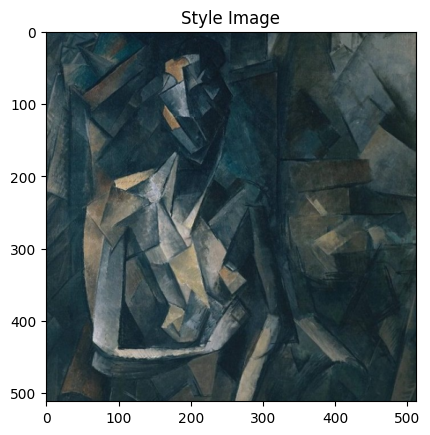

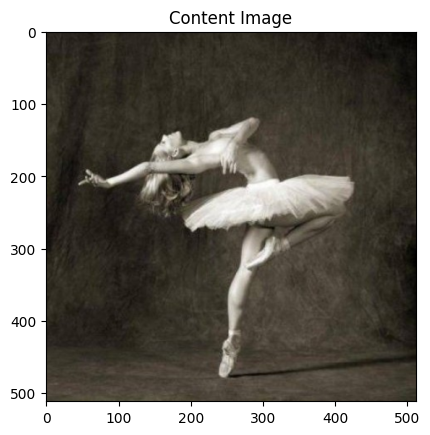

In [6]:
unloader = transforms.ToPILImage()

plt.ion()


def imshow(tensor: torch.Tensor, title: str | None = None) -> None:
    image = tensor.cpu().clone()
    image = image.squeeze(0)
    image = unloader(image)
    plt.imshow(image)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)


plt.figure()
imshow(style_img, title="Style Image")

plt.figure()
imshow(content_img, title="Content Image")

## 3. Content loss

Content loss measures whether the generated image still has similar high-level structure to the content image. Here, *content* means the larger shapes and layout that VGG19 detects, not the exact pixel colors.

The target feature map comes from the original content image and is detached so it stays fixed during optimization. The generated image changes, but the target we compare against should not.

This module returns the unchanged input because it is inserted inside VGG19 as a transparent checkpoint. It records `self.loss` for later, then lets the feature maps continue through the remaining layers.


In [ ]:
import torch.nn as nn
import torch.nn.functional as F


class ContentLoss(nn.Module):
    def __init__(self, target: torch.Tensor) -> None:
        super().__init__()
        self.target = target.detach()
        self.loss = torch.tensor(0.0, device=target.device)

    def forward(self, input: torch.Tensor) -> torch.Tensor:
        self.loss = F.mse_loss(input, self.target)
        return input

## 4. Style loss and the Gram matrix

Style loss measures whether the generated image has visual patterns similar to the style image. Here, *style* means texture, color relationships, and brush-stroke-like patterns more than exact object position.

For future me: `ContentLoss` compares feature maps directly, so it cares about *where* image structure appears. `StyleLoss` compares Gram matrices, so it cares about which feature maps tend to activate together across the image.

In [ ]:
def gram_matrix(input: torch.Tensor) -> torch.Tensor:
    batch_size, channels, height, width = input.size()

    # VGG gives feature maps as [batch, channels, height, width].
    # For style, each channel is one visual detector map.
    # Reshape so each row is one detector map and each column is one image position.
    features = input.view(batch_size * channels, height * width)

    # Multiplying by the transpose compares every detector map with every other one.
    # The result is a feature-relationship table: this is the Gram matrix.
    gram = torch.mm(features, features.t())

    # Divide by the number of values so larger feature maps do not dominate the loss.
    return gram.div(batch_size * channels * height * width)

In [ ]:
class StyleLoss(nn.Module):
    def __init__(self, target_feature: torch.Tensor) -> None:
        super().__init__()
        # Store the style image's feature-relationship table as the fixed target.
        self.target = gram_matrix(target_feature).detach()
        self.loss = torch.tensor(0.0, device=target_feature.device)

    def forward(self, input: torch.Tensor) -> torch.Tensor:
        # Compare the current generated image's relationships to the style target.
        gram = gram_matrix(input)
        self.loss = F.mse_loss(gram, self.target)
        # Pass the original feature maps onward so the rest of VGG still runs.
        return input

## 5. Load VGG19 and normalize inputs

VGG19 is the fixed visual measuring tool for this notebook. We use `.features` because the convolution layers produce the internal feature maps needed by `ContentLoss` and `StyleLoss`; the final classifier is not useful for style transfer.

A useful mental model: VGG19 creates the visual descriptions, while `ContentLoss` and `StyleLoss` compare those descriptions. The loss layers do not create new features by themselves; they are checkpoints inserted after selected VGG convolution layers.

During optimization, VGG19's pretrained weights stay fixed. The thing that changes is the generated image's pixels, because the optimizer pushes that image toward lower content/style loss.

The pretrained VGG19 weights expect RGB channels to be normalized with the same mean and standard deviation used during training. The `Normalization` module applies that adjustment inside the model pipeline, before the image reaches VGG's feature layers.

`register_buffer(...)` stores the mean and standard deviation on the module without treating them as trainable weights. That means they move with the module to CUDA/CPU, but the optimizer will not try to learn them.


In [ ]:
from torchvision.models import VGG19_Weights, vgg19

# Load pretrained VGG19 and keep only the feature-extractor layers.
# Style transfer uses internal feature maps, not the final ImageNet classifier.
# Later we will insert ContentLoss/StyleLoss checkpoints into these layers.
cnn = vgg19(weights=VGG19_Weights.DEFAULT).features.eval().to(device)

# These are the RGB channel statistics VGG19 was trained with.
# Normalizing with the same numbers makes our images look familiar to VGG.
cnn_normalization_mean = torch.tensor([0.485, 0.456, 0.406], device=device)
cnn_normalization_std = torch.tensor([0.229, 0.224, 0.225], device=device)


class Normalization(nn.Module):
    def __init__(self, mean: torch.Tensor, std: torch.Tensor) -> None:
        super().__init__()
        # Register buffers so mean/std follow the module to CUDA/CPU,
        # but are not treated as trainable model weights.
        # view(-1, 1, 1) reshapes [R, G, B] into [channels, 1, 1]
        # so PyTorch can apply each value across the full image.
        self.register_buffer("mean", mean.clone().detach().view(-1, 1, 1))
        self.register_buffer("std", std.clone().detach().view(-1, 1, 1))

    def forward(self, img: torch.Tensor) -> torch.Tensor:
        # Convert image values from the usual 0..1 tensor range into
        # the normalized range expected by pretrained VGG19.
        # This prepares a VGG-readable version; it does not permanently change
        # the generated image tensor that the optimizer is updating.
        return (img - self.mean) / self.std